# 01 · La hiérarchie et les prévisions de base

**Bloc 2 · W37, notebook 1 sur 4.** Dans ce notebook, on construit l'objet à réconcilier et on montre
pourquoi il faut le réconcilier.

| Étape | Ce qu'on fait | Ce qu'on regarde |
|---|---|---|
| 1 | Générer 4 séries feuilles (région × canal) | la formule du générateur |
| 2 | Agréger : 4 feuilles → 2 régions | la **matrice de sommation `S`** |
| 3 | Visualiser les niveaux | les séries par niveau |
| 4 | Découper train / test | la règle anti-fuite |
| 5 | Prévoir chaque série **indépendamment** | `AutoETS`, `fitted=True` |
| 6 | Constater l'incohérence | région ≠ somme de ses canaux |
| 7 | Extraire les résidus in-sample | la matière première de `W` (notebook 02) |

> Exécution : `uv run jupyter lab`, puis ouvrir ce fichier (voir `02_mint_from_scratch/TUTORIEL.md`).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.data import build_hierarchy, make_region_channel_data, train_test_split, to_wide
from w37_reconciliation.forecasting import fit_base_forecasts, residual_matrix

viz.setup()
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)

## 1. Les données : 2 régions × 2 canaux

Chaque **feuille** `(région, canal)` est une série trimestrielle de 80 points (2015 → 2034) :

$$y_t = \underbrace{100 + 30\cdot\mathbb{1}_{\text{Bretagne}} + 20\cdot\mathbb{1}_{\text{GMS}}}_{\text{niveau}}
\; + \; \underbrace{10 \sin(2\pi t / 4)}_{\text{saisonnalité annuelle}}
\; + \; \underbrace{\textstyle\sum_{s \le t} \varepsilon_s}_{\text{marche aléatoire}},
\qquad \varepsilon_s \sim \mathcal N(0, 1.5^2)$$

C'est exactement le générateur du squelette du plan (graine 0). Les feuilles sont **indépendantes**
entre elles. On ne génère que les feuilles : les agrégats en seront les sommes exactes.

In [2]:
df = make_region_channel_data(n=80, seed=0)
display(df.head(6))
print(df.groupby(["Region", "Canal"]).y.agg(["count", "mean", "std"]).round(1))

,ds,Region,Canal,y
0,2015-01-01,Bretagne,GMS,150.189
1,2015-04-01,Bretagne,GMS,159.990
2,2015-07-01,Bretagne,GMS,150.951
3,2015-10-01,Bretagne,GMS,141.108
4,2016-01-01,Bretagne,GMS,150.305
5,2016-04-01,Bretagne,GMS,160.847


                 count   mean   std
Region    Canal                    
Bretagne  GMS       80  151.9   9.5
          RHD       80  128.2   7.9
PaysLoire GMS       80  120.7   8.2
          RHD       80   99.4  10.3


## 2. La matrice de sommation `S`

`aggregate` produit trois objets :

- `Y_df` : toutes les séries (agrégats **et** feuilles) au format long `unique_id, ds, y` ;
- `S_df` : la matrice de sommation ;
- `tags` : la liste des séries de chaque niveau.

**Lecture de `S`.** Il y a une ligne par série (m = 6) et une colonne par feuille (nb = 4). La case (i, j) vaut 1 si
la feuille j entre dans la série i. Les agrégats viennent d'abord, puis les feuilles, où `S` contient
l'identité. Toute la hiérarchie tient dans une égalité :

$$\mathbf y_t = S\, \mathbf b_t, \qquad \mathbf y_t \in \mathbb R^{m},\; \mathbf b_t \in \mathbb R^{nb}$$

In [3]:
hier = build_hierarchy(df)
S, order = hier.S, hier.order
labels = viz.short(order)
display(hier.S_df.set_index("unique_id").astype(int))
print("niveaux :", {k: list(v) for k, v in hier.tags.items()})

,Bretagne/GMS,Bretagne/RHD,PaysLoire/GMS,PaysLoire/RHD
unique_id,,,,
Bretagne,1,1,0,0
PaysLoire,0,0,1,1
Bretagne/GMS,1,0,0,0
Bretagne/RHD,0,1,0,0
PaysLoire/GMS,0,0,1,0
PaysLoire/RHD,0,0,0,1


niveaux : {'Region': ['Bretagne', 'PaysLoire'], 'Region/Canal': ['Bretagne/GMS', 'Bretagne/RHD', 'PaysLoire/GMS', 'PaysLoire/RHD']}


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


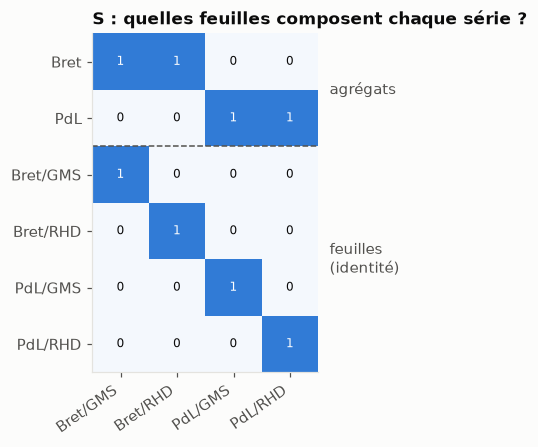

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
viz.heatmap(ax, S, labels_x=labels[2:], labels_y=labels, fmt="{:.0f}", vmax=1.6, colorbar=False,
            title="S : quelles feuilles composent chaque série ?")
ax.axhline(1.5, color=viz.TEXT_2, lw=1, ls="--")
ax.text(3.7, 0.5, "agrégats", va="center", color=viz.TEXT_2)
ax.text(3.7, 3.5, "feuilles\n(identité)", va="center", color=viz.TEXT_2)
plt.show()

**Vérification.** Sur les données observées, la relation $\mathbf y = S\mathbf b$ tient exactement :
les historiques sont **cohérents par construction**.

In [5]:
Y = to_wide(hier.Y_df, order).to_numpy()          # (80 × 6), colonnes dans l'ordre de S
B = Y[:, 2:]                                      # les 4 feuilles
print("max |Y − S·b| sur l'historique :", np.abs(Y - B @ S.T).max())

max |Y − S·b| sur l'historique : 0.0


## 3. Les séries, niveau par niveau

En haut, les 2 régions ; en bas, un petit graphique par feuille. On s'interdit de mettre 4 couleurs sur un même
graphique : au-delà de 3 séries, on passe aux petits multiples.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


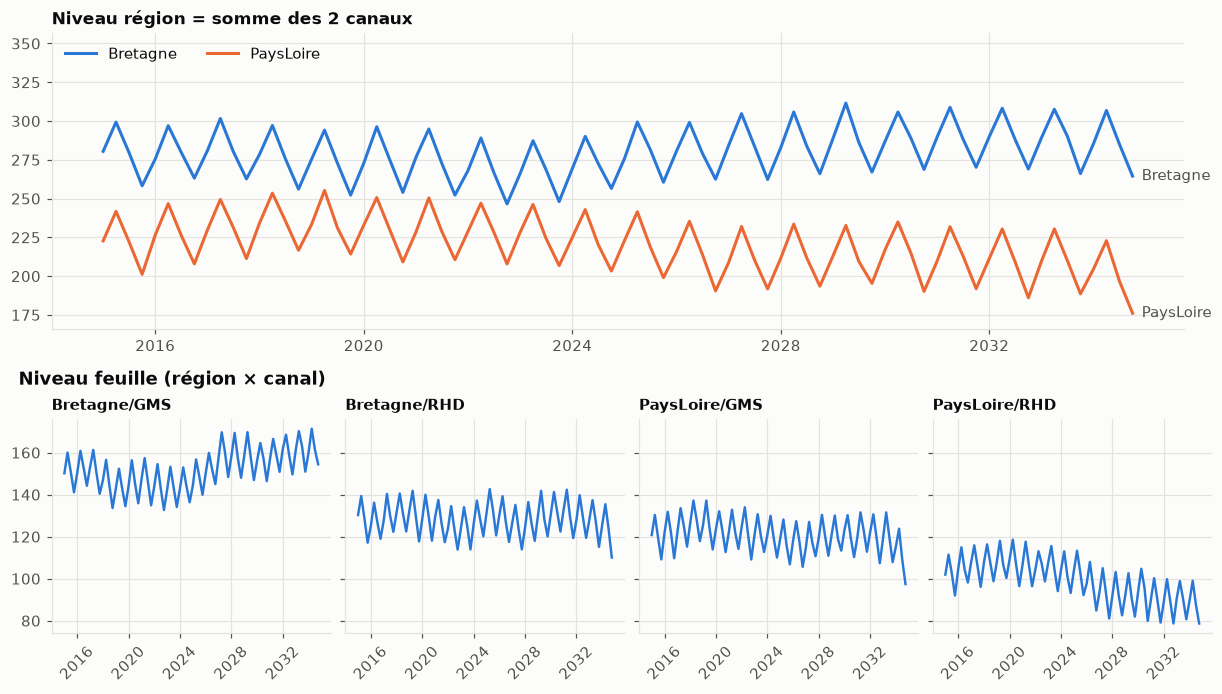

In [6]:
Yw = to_wide(hier.Y_df, order)
fig = plt.figure(figsize=(11, 6.2), layout="constrained")
top, bottom = fig.subfigures(2, 1, height_ratios=[1.1, 1])
ax = top.subplots()
for col, color in zip(order[:2], viz.SERIES):
    ax.plot(Yw.index, Yw[col], color=color, label=col)
    ax.annotate(col, (Yw.index[-1], Yw[col].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                color=viz.TEXT_2, va="center")
ax.set_title("Niveau région = somme des 2 canaux")
ax.set_ylim(Yw[order[:2]].min().min() - 10, Yw[order[:2]].max().max() + 45)
ax.legend(loc="upper left", ncol=2)
axs = bottom.subplots(1, 4, sharey=True)
for a, col in zip(axs, order[2:]):
    a.plot(Yw.index, Yw[col], color=viz.BLUE, lw=1.6)
    a.set_title(col, fontsize=10)
    a.tick_params(axis="x", labelrotation=45)
bottom.suptitle("Niveau feuille (région × canal)", x=0.01, ha="left", fontweight="semibold")
plt.show()

## 4. Découpage train / test, et la règle anti-fuite

On garde les **8 derniers trimestres** pour le test (h = 8). La règle du bloc 2 est la suivante :

> **`W` ne voit que des résidus one-step-ahead calculés sur le train.**

Si on estimait `W` sur des résidus qui couvrent la période de test, la réconciliation paraîtrait excellente en
backtest et décevrait en production.

In [7]:
train, test = train_test_split(hier.Y_df, h=8)
print("train :", train.ds.min().date(), "→", train.ds.max().date(), f"({train.ds.nunique()} trimestres)")
print("test  :", test.ds.min().date(), "→", test.ds.max().date(), f"({test.ds.nunique()} trimestres)")
assert train.ds.max() < test.ds.min()

train : 2015-01-01 → 2032-10-01 (72 trimestres)
test  : 2033-01-01 → 2034-10-01 (8 trimestres)


## 5. Prévisions de base : un modèle par série, indépendamment

`AutoETS(season_length=4)` est ajusté sur **chacune** des 6 séries, agrégats compris. `SeasonalNaive` sert de
point de comparaison.

`fitted=True` est **indispensable** : il conserve les valeurs ajustées in-sample, donc les résidus. Sans ces
résidus, on ne peut pas estimer `W`, et `mint_shrink` devient impossible.

In [8]:
Y_hat, Y_fit = fit_base_forecasts(train, h=8)
display(Y_hat.head(4))
display(Y_fit.head(4))

,unique_id,ds,AutoETS,SeasonalNaive
0,Bretagne,2033-01-01,288.658,289.942
1,Bretagne,2033-04-01,308.939,308.257
2,Bretagne,2033-07-01,288.465,287.902
3,Bretagne,2033-10-01,269.053,269.053


,unique_id,ds,y,AutoETS,SeasonalNaive
0,Bretagne,2015-01-01,280.471,280.442,NaN
1,Bretagne,2015-04-01,299.323,300.752,NaN
2,Bretagne,2015-07-01,279.718,278.849,NaN
3,Bretagne,2015-10-01,258.238,260.305,NaN


## 6. Les prévisions de base ne somment pas

Chaque modèle ignore les autres. La prévision de la région Bretagne n'a donc aucune raison d'être égale à la somme
des prévisions Bretagne/GMS et Bretagne/RHD. C'est exactement l'écart qu'un comité S&OP arbitre à la main chaque
mois. Ici, il reste faible (≤ 0,33 unité, sur des valeurs autour de 200), mais il n'est jamais nul.

In [9]:
yhat = to_wide(Y_hat, order, "AutoETS")
rows = []
for region in order[:2]:
    leaves = [c for c in order[2:] if c.startswith(region + "/")]
    rows.append(pd.DataFrame({"région": region, "prévision région": yhat[region],
                              "somme des canaux": yhat[leaves].sum(axis=1)}))
incoh = pd.concat(rows)
incoh["écart"] = incoh["prévision région"] - incoh["somme des canaux"]
display(incoh.reset_index().rename(columns={"ds": "trimestre"}).head(8))

,trimestre,région,prévision région,somme des canaux,écart
0,2033-01-01,Bretagne,288.658,288.631,2.748e-02
1,2033-04-01,Bretagne,308.939,308.931,8.682e-03
2,2033-07-01,Bretagne,288.465,288.430,3.493e-02
3,2033-10-01,Bretagne,269.053,269.053,5.716e-05
4,2034-01-01,Bretagne,288.658,288.631,2.748e-02
5,2034-04-01,Bretagne,308.939,308.931,8.682e-03
6,2034-07-01,Bretagne,288.465,288.430,3.493e-02
7,2034-10-01,Bretagne,269.053,269.053,5.716e-05


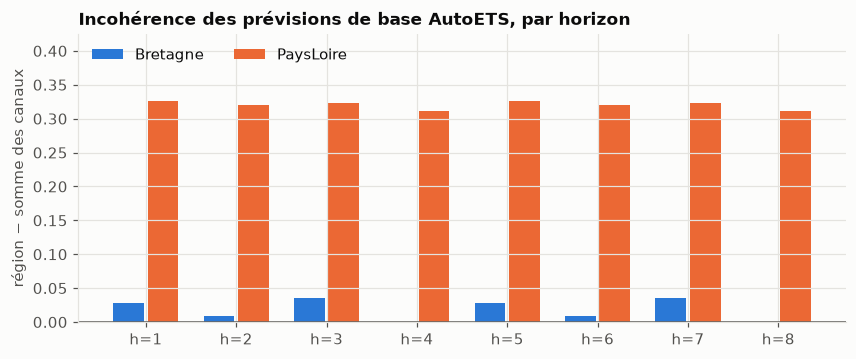

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(8); w = 0.38
for k, (region, color) in enumerate(zip(order[:2], viz.SERIES)):
    gap = incoh.loc[incoh["région"] == region, "écart"].to_numpy()
    ax.bar(x + (k - 0.5) * w, gap, width=w - 0.04, color=color, label=region)
ax.axhline(0, color=viz.TEXT_2, lw=1)
ax.set_xticks(x, [f"h={i + 1}" for i in x])
ax.set_ylabel("région − somme des canaux")
ax.set_title("Incohérence des prévisions de base AutoETS, par horizon")
ax.set_ylim(0, incoh["écart"].max() * 1.3)
ax.legend(loc="upper left", ncol=2)
plt.show()

## 7. Les résidus in-sample, matière première de `W`

$e_{t,i} = y_{t,i} - \hat y_{t|t-1,\,i}$ : erreur one-step de la série i à l'instant t, calculée **sur le
train uniquement**. On les empile dans une matrice **E** de taille T × m, où les colonnes suivent l'ordre des lignes
de `S`.

Deux propriétés à vérifier avant de les utiliser :

- **moyenne ≈ 0** : MinT suppose des prévisions non biaisées ;
- **mêmes instants pour toutes les séries** : sans cet alignement, la covariance entre séries n'a pas de sens.

In [11]:
E = residual_matrix(Y_fit, order)
T, m = E.shape
print(f"E : {T} instants × {m} séries")
stats = pd.DataFrame({"moyenne": E.mean(0), "écart-type": E.std(0), "moyenne / écart-type": E.mean(0) / E.std(0)},
                     index=order)
display(stats)

E : 72 instants × 6 séries


,moyenne,écart-type,moyenne / écart-type
Bretagne,0.114,1.897,0.060
PaysLoire,-0.260,1.991,-0.131
Bretagne/GMS,0.125,1.382,0.091
Bretagne/RHD,-0.012,1.350,-0.009
PaysLoire/GMS,-0.046,1.478,-0.031
PaysLoire/RHD,-0.199,1.578,-0.126


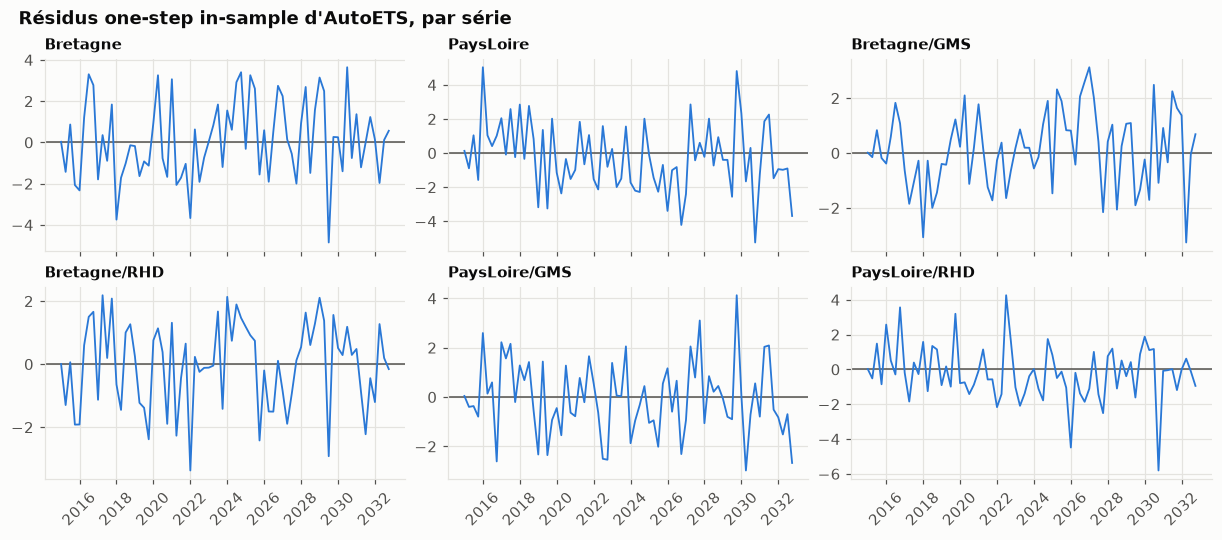

In [12]:
ds = to_wide(Y_fit, order).dropna().index[-T:]
fig, axs = plt.subplots(2, 3, figsize=(11, 4.8), sharex=True, layout="constrained")
for a, j in zip(axs.flat, range(m)):
    a.axhline(0, color=viz.TEXT_2, lw=1)
    a.plot(ds, E[:, j], color=viz.BLUE, lw=1.2)
    a.set_title(order[j], fontsize=10)
    a.tick_params(axis="x", labelrotation=45)
fig.suptitle("Résidus one-step in-sample d'AutoETS, par série", x=0.01, ha="left", fontweight="semibold")
plt.show()

## À retenir

- Toute la hiérarchie tient dans **`S`** : $\mathbf y = S\mathbf b$.
- Des modèles par série produisent des prévisions **incohérentes** : jusqu'à environ 0,3 unité par trimestre ici
  (Pays de la Loire). C'est petit sur ce jeu jouet, mais ce n'est pas nul, et un comité S&OP le verra.
- Les résidus in-sample **alignés dans le temps** forment la matrice **E** (72 × 6). Le notebook **02** en tire la
  covariance `W`, puis la rétrécit avec Schäfer–Strimmer.